In [3]:
import pandas as pd
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

def generate_sandalwood_data(num_samples=1000):
    # 1. Independent Variables (Features)
    age = np.random.uniform(5, 25, num_samples)  # Age in years (5 to 25)
    rainfall = np.random.uniform(500, 2000, num_samples)  # Annual rainfall in mm
    temp_avg = np.random.uniform(22, 35, num_samples)  # Avg temp in Celsius
    soil_ph = np.random.uniform(6.0, 8.5, num_samples)  # Soil pH (Ideal 6.5-7.5)
    
    # Altitude for Karnataka plateau (approx 600m)
    altitude = np.random.normal(600, 50, num_samples) 

    # 2. The Relationship Logic (Based on research)
    # Heartwood usually starts after age 7-8. 
    # It grows faster in hot/dry regions but volume is higher in moist soil.
    
    # Base yield logic: starts at 0, grows exponentially after age 8
    yield_kg = np.where(age < 8, 0, (age - 7) * 1.2) 
    
    # Weather & Soil impact factors
    rainfall_factor = 1 + (rainfall - 1000) / 5000  # Slight boost for rain
    temp_factor = 1 + (temp_avg - 28) / 100        # Thrives in heat
    ph_factor = np.where((soil_ph >= 6.5) & (soil_ph <= 7.5), 1.1, 0.9)
    
    # Final Yield Calculation with some random 'noise' (real life isn't perfect)
    noise = np.random.normal(0, 1.5, num_samples)
    final_yield = (yield_kg * rainfall_factor * temp_factor * ph_factor) + noise
    
    # Ensure no negative yields
    final_yield = np.clip(final_yield, 0, None)

    # 3. Create DataFrame
    df = pd.DataFrame({
        'Tree_ID': range(1, num_samples + 1),
        'Age_Years': np.round(age, 1),
        'Rainfall_mm': np.round(rainfall, 0),
        'Avg_Temp_C': np.round(temp_avg, 1),
        'Soil_pH': np.round(soil_ph, 2),
        'Altitude_m': np.round(altitude, 0),
        'Heartwood_Yield_Kg': np.round(final_yield, 2)
    })
    
    return df

# Generate and save
df_sandalwood = generate_sandalwood_data(2000)
df_sandalwood.to_csv('sandalwood_yield_data.csv', index=False)

print("Dataset generated successfully!")
print(df_sandalwood.head())

Dataset generated successfully!
   Tree_ID  Age_Years  Rainfall_mm  Avg_Temp_C  Soil_pH  Altitude_m  \
0        1       12.5        893.0        29.4     7.62       648.0   
1        2       24.0        870.0        32.5     6.43       656.0   
2        3       19.6       1859.0        31.9     8.18       503.0   
3        4       17.0        874.0        24.0     7.53       649.0   
4        5        8.1        908.0        23.9     6.39       559.0   

   Heartwood_Yield_Kg  
0                4.80  
1               18.91  
2               17.87  
3               11.28  
4                0.00  


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data
df = pd.read_csv('sandalwood_yield_data.csv')

# Check the first 5 rows and basic stats
print(df.head())
print(df.describe())

   Tree_ID  Age_Years  Rainfall_mm  Avg_Temp_C  Soil_pH  Altitude_m  \
0        1       12.5        893.0        29.4     7.62       648.0   
1        2       24.0        870.0        32.5     6.43       656.0   
2        3       19.6       1859.0        31.9     8.18       503.0   
3        4       17.0        874.0        24.0     7.53       649.0   
4        5        8.1        908.0        23.9     6.39       559.0   

   Heartwood_Yield_Kg  
0                4.80  
1               18.91  
2               17.87  
3               11.28  
4                0.00  
           Tree_ID    Age_Years  Rainfall_mm   Avg_Temp_C      Soil_pH  \
count  2000.000000  2000.000000   2000.00000  2000.000000  2000.000000   
mean   1000.500000    14.970950   1244.59550    28.451400     7.219570   
std     577.494589     5.844809    432.86888     3.743801     0.718257   
min       1.000000     5.100000    500.00000    22.000000     6.000000   
25%     500.750000     9.800000    876.00000    25.200000  

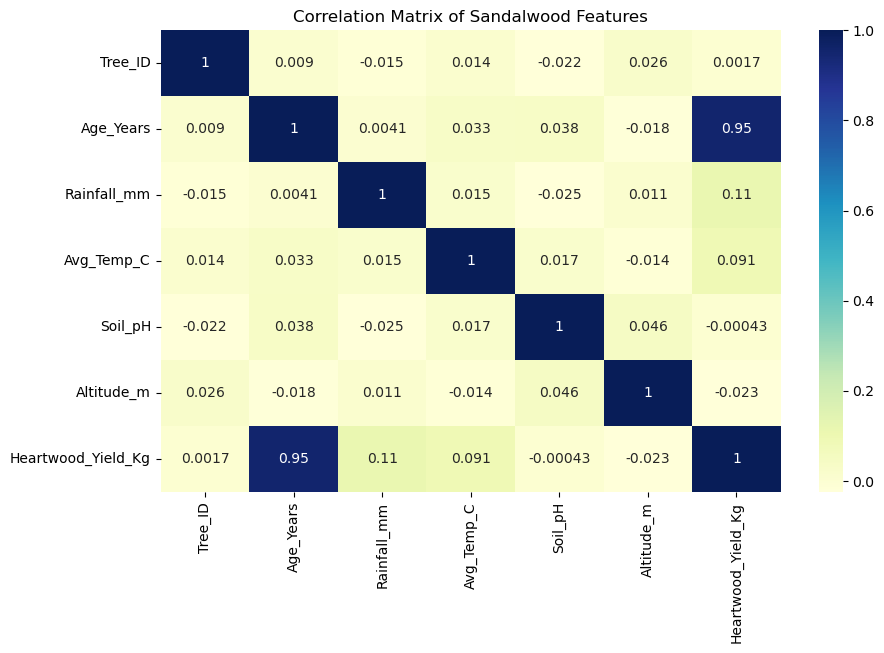

In [5]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='YlGnBu')
plt.title("Correlation Matrix of Sandalwood Features")
plt.show()

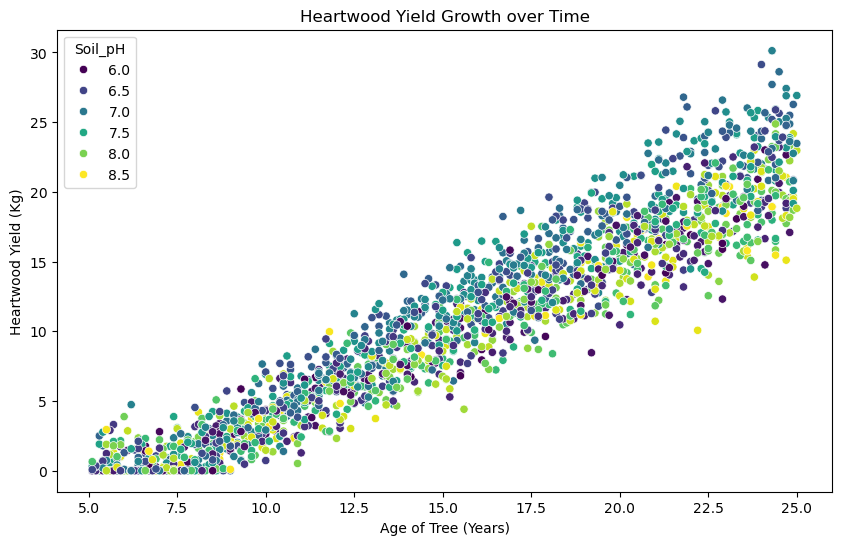

In [4]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age_Years', y='Heartwood_Yield_Kg', hue='Soil_pH', palette='viridis')
plt.title("Heartwood Yield Growth over Time")
plt.xlabel("Age of Tree (Years)")
plt.ylabel("Heartwood Yield (Kg)")
plt.show()

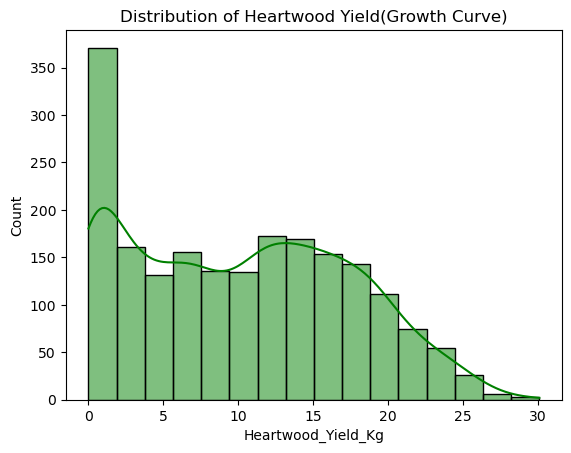

In [6]:
sns.histplot(df['Heartwood_Yield_Kg'], kde=True, color='green')
plt.title("Distribution of Heartwood Yield(Growth Curve)")
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Define Features (X) and Target (y)
# We drop 'Tree_ID' because it's just a label and has no predictive power.
X = df.drop(['Tree_ID', 'Heartwood_Yield_Kg'], axis=1)
y = df['Heartwood_Yield_Kg']

# 2. Split the data (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data split and scaled successfully!")
print(f"Training set size: {X_train_scaled.shape[0]} trees")
print(f"Testing set size: {X_test_scaled.shape[0]} trees")

Data split and scaled successfully!
Training set size: 1600 trees
Testing set size: 400 trees


In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Initialize the Model
# n_estimators=100 means we are using 100 'decision trees' to get an average
model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Train (Fit) the model
model.fit(X_train_scaled, y_train)

# 3. Make Predictions on the Test Set
y_pred = model.predict(X_test_scaled)

# 4. Evaluate the performance
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Model R-squared Score: {r2:.4f}")
print(f"Mean Absolute Error: {mae:.2f} Kg")

Model R-squared Score: 0.9537
Mean Absolute Error: 1.22 Kg


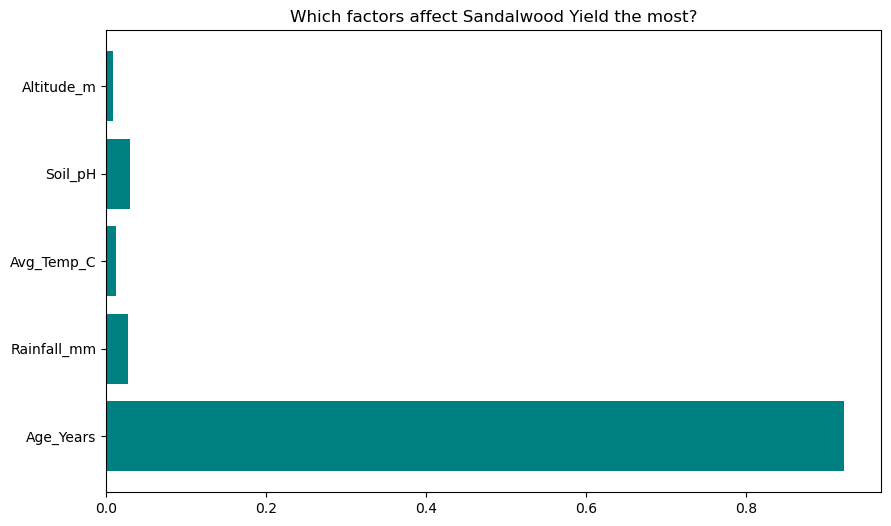

In [9]:
import matplotlib.pyplot as plt

# Get feature importance from the model
importances = model.feature_importances_
feature_names = X.columns

# Visualize
plt.figure(figsize=(10, 6))
plt.barh(feature_names, importances, color='teal')
plt.title("Which factors affect Sandalwood Yield the most?")
plt.show()

In [10]:
def predict_my_tree(age, rainfall, temp, ph, altitude):
    # 1. Wrap inputs into a DataFrame (must match the training columns)
    input_data = pd.DataFrame([[age, rainfall, temp, ph, altitude]], 
                              columns=['Age_Years', 'Rainfall_mm', 'Avg_Temp_C', 'Soil_pH', 'Altitude_m'])
    
    # 2. Scale the input using the SAME scaler from Week 2
    input_scaled = scaler.transform(input_data)
    
    # 3. Predict
    prediction = model.predict(input_scaled)
    
    return f"Estimated Heartwood Yield: {prediction[0]:.2f} Kg"

# --- TEST IT ---
# Example: A 20-year-old tree in Bidar (low rainfall, high temp)
print(predict_my_tree(20, 800, 32, 7.2, 615))

Estimated Heartwood Yield: 16.75 Kg


In [11]:
import joblib

# Save the model and the scaler (you need both!)
joblib.dump(model, 'sandalwood_model.pkl')
joblib.dump(scaler, 'sandalwood_scaler.pkl')

print("Model and Scaler saved as .pkl files!")

Model and Scaler saved as .pkl files!


In [12]:
import streamlit as st
import pandas as pd
import joblib
import numpy as np

# 1. Load the saved model and scaler
model = joblib.load('sandalwood_model.pkl')
scaler = joblib.load('sandalwood_scaler.pkl')

# 2. Set up the Web Page UI
st.title("🌳 Sandal-ML: Yield Predictor")
st.write("Enter the tree and environmental conditions to estimate Heartwood yield.")

# 3. Create Inputs (Sliders and Boxes)
age = st.slider("Tree Age (Years)", 5, 25, 12)
rainfall = st.number_input("Annual Rainfall (mm)", 500, 2500, 1000)
temp = st.slider("Average Temperature (°C)", 20, 40, 28)
ph = st.slider("Soil pH", 5.0, 9.0, 7.0)
altitude = st.number_input("Altitude (meters)", 300, 1500, 600)

# 4. Prediction Logic
if st.button("Predict Yield"):
    # Prepare data for prediction
    features = pd.DataFrame([[age, rainfall, temp, ph, altitude]], 
                            columns=['Age_Years', 'Rainfall_mm', 'Avg_Temp_C', 'Soil_pH', 'Altitude_m'])
    
    # Scale and Predict
    features_scaled = scaler.transform(features)
    prediction = model.predict(features_scaled)
    
    # Display Result
    st.success(f"Estimated Heartwood Yield: {prediction[0]:.2f} Kg")
    
    if prediction[0] == 0:
        st.warning("Note: Sandalwood usually takes 8+ years to develop heartwood.")

2026-03-08 11:02:38.417 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-08 11:02:38.799 
  command:

    streamlit run C:\Users\arkad\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-03-08 11:02:38.800 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-08 11:02:38.800 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-08 11:02:38.801 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-08 11:02:38.802 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-08 11:02:38.802 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-08 11:02:38.803 Thread 'MainThread': mi